# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

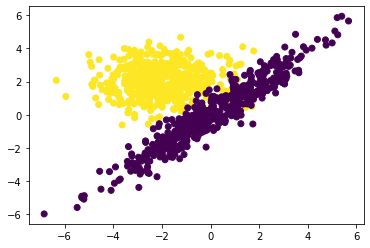

In [3]:
synth= syn.synthetic_data_generator(n=500,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [4]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

#x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [5]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.047912,3.130559,2.939331,1.225359
1,-0.726534,1.580683,-3.215417,-1.887577
2,-2.817116,2.372523,0.896092,0.068843
3,-0.864408,-0.504422,2.610837,-2.457975
4,-1.086113,1.085399,1.184620,-1.066234


# ML model setup

In [6]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [7]:
# Creates and train ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')

xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


0.915

In [8]:
# Creates and train ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.92

# Shap test

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


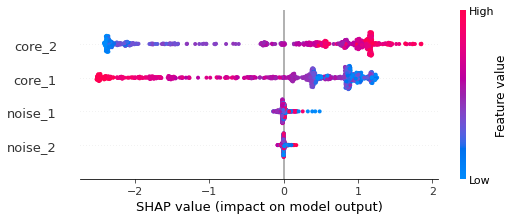

In [9]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [10]:
shap_values[1]

.values =
array([0.84512955, 1.166302  , 0.00346286, 0.00465241], dtype=float32)

.base_values =
-0.019608617

.data =
array([-3.0637443 ,  3.15488585, -1.97102946,  1.45862907])

In [11]:
sh_vals= pd.DataFrame(shap_values[1].values, train.columns).T

sh_vals

,core_1,core_2,noise_1,noise_2
0,0.84513,1.166302,0.003463,0.004652


In [12]:
train.head()

,core_1,core_2,noise_1,noise_2
281,-1.271372,2.997796,-3.344602,-3.728011
42,-3.063744,3.154886,-1.971029,1.458629
255,-3.897386,1.288271,3.708634,1.350112
906,2.717708,2.555114,0.571054,2.428921
394,-3.549603,3.985841,1.348674,0.659009


In [13]:
labels_train.head()

,target
281,1.0
42,1.0
255,1.0
906,0.0
394,1.0


# FAR test - Global version with no retraining

In [14]:
num_fts= len(x_syn.columns)

replace_ft= far.replace_values(x_syn, x_syn.columns, num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft, test, labels_test, verbose=True)

--- 0.24 seconds ---


In [15]:
acc_all_fts= xgb_acc

# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [16]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     4.972279e-01
core_1     4.924132e-01
noise_1    1.035891e-02
noise_2    1.567756e-16
dtype: float64

In [17]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.369795
noise_1    0.240352
core_1     0.196971
noise_2    0.182685
dtype: float64

In [18]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.368073
noise_1    0.245057
core_1     0.188347
noise_2    0.187769
dtype: float64

In [19]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     4.984380e-01
core_1     4.957662e-01
noise_1    5.795791e-03
noise_2    5.984796e-17
dtype: float64

# FAR test - PageRank Global version with no retraining

In [20]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= far.p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.p_matrix_to_row_stochastic_matrix(p_matrix4)

In [21]:
# using networkx lib

In [49]:
far.run_lib_pr(st_matrix1, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.497228
core_1     0.492413
noise_1    0.010359
noise_2    0.000000
dtype: float64

In [50]:
far.run_lib_pr(st_matrix2, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.356442
noise_1    0.226619
noise_2    0.223256
core_1     0.193683
dtype: float64

In [51]:
far.run_lib_pr(st_matrix3, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.354627
noise_1    0.230849
noise_2    0.229093
core_1     0.185431
dtype: float64

In [52]:
far.run_lib_pr(st_matrix4, x_syn.columns, iteration= 100000, damping_factor= 1, tolerance= 1.0e-12)

core_2     0.498438
core_1     0.495766
noise_1    0.005796
noise_2    0.000000
dtype: float64

In [26]:
# using my PageRank lib

In [27]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.562892
core_2     0.293744
noise_1    0.072409
noise_2    0.070955
dtype: float64

In [28]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_2     0.372005
core_1     0.341074
noise_1    0.143877
noise_2    0.143043
dtype: float64

In [29]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_2     0.376876
core_1     0.331017
noise_1    0.146275
noise_2    0.145832
dtype: float64

In [30]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.564487
core_2     0.292997
noise_1    0.071663
noise_2    0.070853
dtype: float64

# FAR test - Local version - data and target

In [31]:
# the instance to be explained (from train dataset)
target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

#replace_ft[x_syn.columns]= 0

# FAR test - Local version with no retraining

In [32]:
num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft, target_inst, target_labl, verbose=True)

--- 0.11 seconds ---


In [33]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [34]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.2
core_1     0.2
noise_2    0.2
core_2     0.2
dtype: float64

In [35]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.2
core_1     0.2
noise_2    0.2
core_2     0.2
dtype: float64

In [36]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.25
core_1     0.25
core_2     0.25
noise_1    0.25
dtype: float64

In [37]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.25
core_1     0.25
core_2     0.25
noise_1    0.25
dtype: float64

# FAR test - Knn-only local version

In [38]:
# neighborhood with similar elements, i.e., only instances from the same class of target instance

neigh_lb_test= labels_test[labels_test.target== target_labl.iloc[0,0]]

neigh_ft_test= test.loc[neigh_lb_test.index]

In [39]:
acc_no_i, acc_no_ij= far.knn_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test, 
                                                     target_inst, target_labl, neighb_size= 0.3, verbose=True)

--- 0.14 seconds ---


In [40]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [41]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.2
core_1     0.2
noise_2    0.2
core_2     0.2
dtype: float64

In [42]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.2
core_1     0.2
noise_2    0.2
core_2     0.2
dtype: float64

In [43]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.25
core_1     0.25
core_2     0.25
noise_1    0.25
dtype: float64

In [44]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.25
core_1     0.25
core_2     0.25
noise_1    0.25
dtype: float64

# FAR test - KnnFold local version

In [45]:
acc_no_i, acc_no_ij= far.knnfold_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test,
                                                         target_inst, target_labl, neighb_size= 0.5, k_folds=10,
                                                         verbose=True)

NameError: name 'StratifiedKFold' is not defined

In [ ]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [ ]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

# FAR test - KnnFold local version PageRank

In [ ]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# converts a matrix to a row stochastic matrix
st_matrix1= far.to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.to_row_stochastic_matrix(p_matrix4)

In [ ]:
# using networkx lib

In [ ]:
far.run_lib_pr(st_matrix1, x_syn.columns)

In [ ]:
far.run_lib_pr(st_matrix2, x_syn.columns)

In [ ]:
far.run_lib_pr(st_matrix3, x_syn.columns)

In [ ]:
far.run_lib_pr(st_matrix4, x_syn.columns)

In [ ]:
# using my PageRank lib

In [ ]:
far.run_my_pr(st_matrix1, x_syn.columns)

In [ ]:
far.run_my_pr(st_matrix2, x_syn.columns)

In [ ]:
far.run_my_pr(st_matrix3, x_syn.columns)

In [ ]:
far.run_my_pr(st_matrix4, x_syn.columns)

# FAR test - Global version with retraining

In [ ]:
repeat_train= 5

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train, labels_test,repeat_train)

acc_no_i, acc_no_ij= far.remove_and_retrain(xgb_model, replace_ft, train, test, labels_train,
                                               labels_test,repeat_train,verbose=True)

In [ ]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [ ]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking